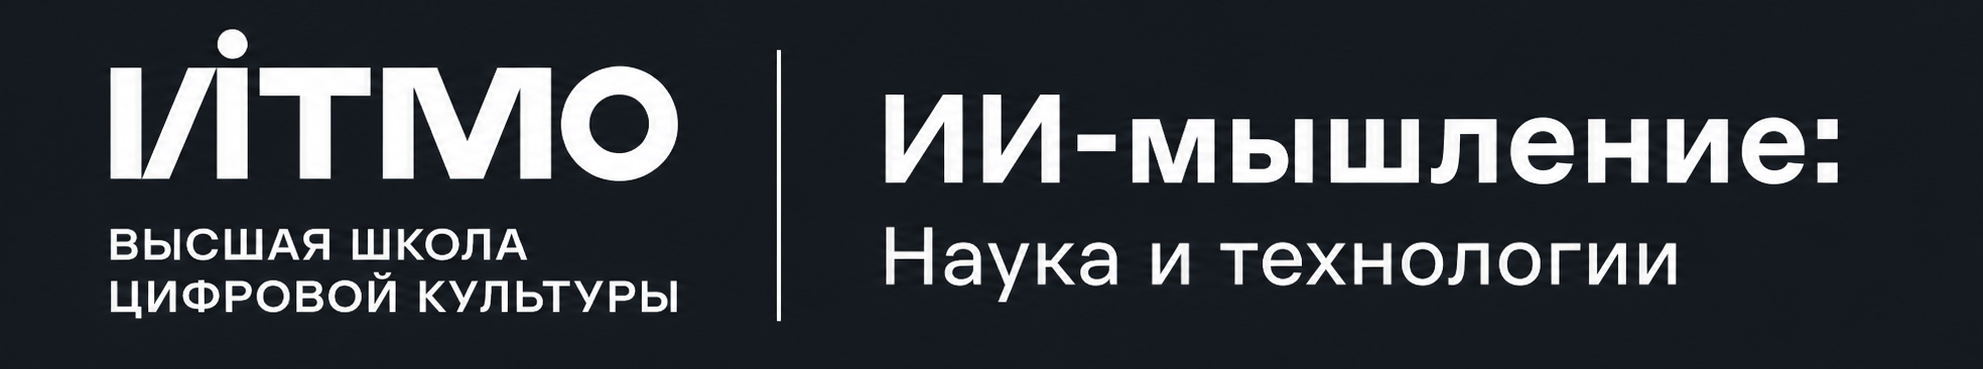

# Неделя 02. Механизм внимания (Attention) и позиционное кодирование (Общий трек)

## Информация
---
> **ФИО:**
> Самойло Александр Александрович
> **ИСУ:** 563081
---

**Цель работы:** Исследовать и реализовать ключевые компоненты архитектуры Transformer, включая механизм внимания Scaled Dot-Product Attention, многоголовое внимание Multi-Head Attention, причинное маскирование (Causal Masking) для генеративных моделей, оптимизацию инференса с использованием KV-кеширования (KV-Cache) и различные схемы позиционного кодирования (Sinusoidal, Learned, RoPE).


## Импорты

In [1]:
# ruff: noqa: F401, E402, I001, F811, E722
import sys

sys.modules['torchvision'] = None

import subprocess


def print_ok(msg="Все проверки пройдены"):
    print(f"\033[92m[OK]\033[0m {msg}")


def print_error(msg=""):
    print(f"\033[91m[ERROR]\033[0m {msg}")


# Проверка и установка недостающих библиотек
required_packages = {'numpy': 'numpy', 'torch': 'torch', 'matplotlib': 'matplotlib', 'pandas': 'pandas'}
for package, pip_name in required_packages.items():
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import numpy as np
import torch

print("Проверка версий библиотек:")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("\nНайдено устройство Apple Silicon (MPS). Вычисления будут выполняться на GPU Mac.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nНайдено устройство CUDA: {torch.cuda.get_device_name(0)}. Вычисления будут выполняться на GPU.")
else:
    device = torch.device("cpu")
    print("\nВычислительные GPU не найдены. Вычисления будут выполняться на CPU.")

DEVICE = device
print(f"Активное устройство для PyTorch: {device}")

# Фиксация случайных сидов для воспроизводимости результатов
import random

def seed_everything(seed: int = 42):
    """
    Фиксирует случайные сиды для воспроизводимости (с проверкой импортированных библиотек).

    seed : int
        Значение сида.
    """
    random.seed(seed)
    
    if 'numpy' in sys.modules or 'numpy' in globals():
        import numpy as np
        np.random.seed(seed)
        
    if 'torch' in sys.modules or 'torch' in globals():
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        
    print_ok(f"Случайные сиды зафиксированы: {seed}")

seed_everything(42)


Проверка версий библиотек:
Python: 3.14.3
NumPy: 2.4.2
PyTorch: 2.10.0+cpu

Вычислительные GPU не найдены. Вычисления будут выполняться на CPU.
Активное устройство для PyTorch: cpu
[OK] Случайные сиды зафиксированы: 42


In [ ]:
# Настройка окружения и импорты
import sys

# Блокируем импорт torchvision для предотвращения конфликта версий библиотеки
sys.modules['torchvision'] = None

import math
import time
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Задание 1. Scaled Dot-Product Attention — реализация с нуля

Механизм scaled dot-product attention вычисляет сходство между query и key, масштабирует его, применяет softmax и взвешивает векторы value.

Формула Scaled Dot-Product Attention:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Реализуйте:**
* Функцию `scaled_dot_product_attention` для вычисления механизма внимания.


In [3]:
def scaled_dot_product_attention(
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    mask: Optional[torch.Tensor] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Вычисляет Scaled Dot-Product Attention.
    """
    d_k = query.size(-1) #размерность ключа
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k) #вычисление скоринговой матрицы
    if mask is not None:
        if mask.dtype == torch.bool:
            scores = scores.masked_fill(mask == 0, float('-inf'))#маскировка запрещённых позиций
        else:
            scores = scores + mask #добавление маски к скоринговой матрице
    attention_weights = F.softmax(scores, dim=-1) #вычисление весов внимания
    out = torch.matmul(attention_weights, value) #взвешшеная сумма векторов значений
    return out, attention_weights


In [4]:
try:
    batch, heads, seq_len, d_k, d_v = 2, 3, 5, 16, 32
    q = torch.randn(batch, heads, seq_len, d_k)
    k = torch.randn(batch, heads, seq_len, d_k)
    v = torch.randn(batch, heads, seq_len, d_v)
    
    output, attn = scaled_dot_product_attention(q, k, v)
    
    # Тест 1: Проверка размерностей
    assert output.shape == (batch, heads, seq_len, d_v), f"Wrong output shape: {output.shape} != {(batch, heads, seq_len, d_v)}"
    assert attn.shape == (batch, heads, seq_len, seq_len), f"Wrong attention shape: {attn.shape} != {(batch, heads, seq_len, seq_len)}"
    
    # Тест 2: Сумма по строкам Softmax равна 1
    row_sums = attn.sum(dim=-1)
    assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5), f"Attention weights do not sum to 1: max={row_sums.max():.4f}"
    
    # Тест 3: Проверка на единичном примере
    q_test = torch.eye(4).unsqueeze(0).unsqueeze(0)
    k_test = q_test.clone()
    v_test = torch.arange(4, dtype=torch.float).unsqueeze(0).unsqueeze(0).unsqueeze(-1).expand(-1, -1, -1, 4)
    out_test, attn_test = scaled_dot_product_attention(q_test, k_test, v_test)
    
    print_ok("scaled_dot_product_attention базовые проверки успешно пройдены!")
except AssertionError as e:
    print_error(f"Тест scaled_dot_product_attention провален: {e}")

[OK] scaled_dot_product_attention базовые проверки успешно пройдены!


In [8]:
# Сравнение с PyTorch и проверка градиентов
# ВАШ КОД ЗДЕСЬ: Сравните выходы вашей реализации scaled_dot_product_attention с PyTorch и проверьте градиенты
seq = seq_len
my_output, my_attn = scaled_dot_product_attention(q, k, v)
pt_output = F.scaled_dot_product_attention(q, k, v)


In [9]:
try:
    assert torch.allclose(my_output, pt_output, atol=1e-5), "Реализации не совпадают!"
    
    # Проверка градиентов
    q_grad = torch.randn(batch, heads, seq, d_k, requires_grad=True)
    k_grad = torch.randn(batch, heads, seq, d_k, requires_grad=True)
    v_grad = torch.randn(batch, heads, seq, d_k, requires_grad=True)
    
    out_grad, _ = scaled_dot_product_attention(q_grad, k_grad, v_grad)
    loss = out_grad.sum()
    loss.backward()
    
    assert q_grad.grad is not None, "Градиент для Q не вычислен"
    assert k_grad.grad is not None, "Градиент для K не вычислен"
    assert v_grad.grad is not None, "Градиент для V не вычислен"
    print_ok("Сравнение с PyTorch и вычисление градиентов успешно проверены!")
except AssertionError as e:
    print_error(f"Тест сравнения с PyTorch провален: {e}")


[OK] Сравнение с PyTorch и вычисление градиентов успешно проверены!


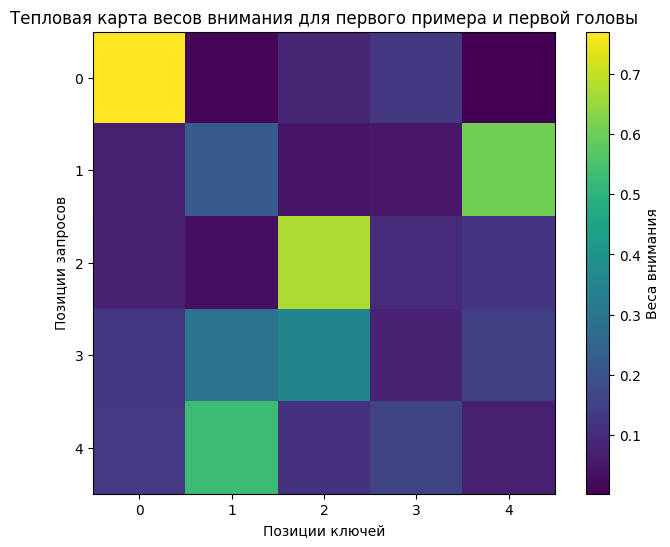

In [10]:
# Визуализация весов внимания
# ВАШ КОД ЗДЕСЬ: Визуализируйте веса внимания с помощью heatmap
plt.figure(figsize=(8, 6))
plt.imshow(my_attn[0, 0].detach().cpu().numpy(), cmap='viridis')
plt.colorbar(label='Веса внимания')
plt.title("Тепловая карта весов внимания для первого примера и первой головы")
plt.xlabel("Позиции ключей")
plt.ylabel("Позиции запросов")
plt.show()


### ***Архитектурный пример***. Внимание при разрешении кореференции

Рассмотрим предложение: **"Маша сказала Пете, что она опоздает"**

Self-Attention позволяет модели выявлять синтаксические и семантические связи независимо от предметной области:
* Запрос (Query) **"она"** должен обращать внимание на **"Маша"** (кореференция местоимения).
* Запрос **"опоздает"** должен связываться с **"она"** (согласование субъекта и действия).


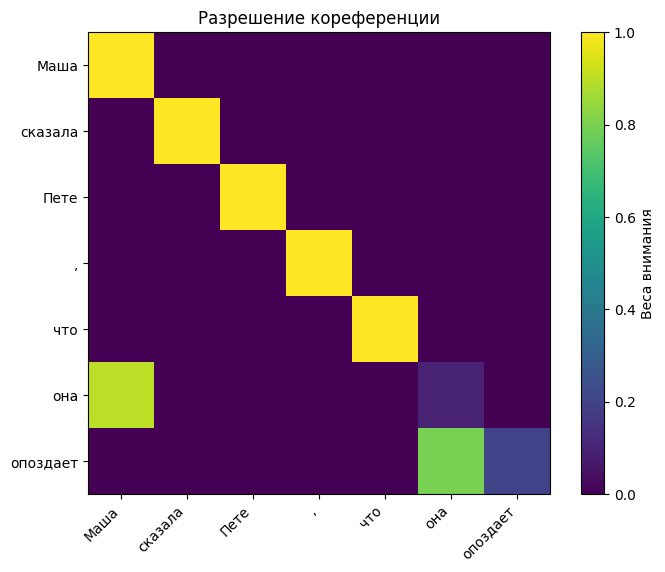

In [11]:
# Пример качественной матрицы Self-Attention для разрешения кореференции
tokens = ["Маша", "сказала", "Пете", ",", "что", "она", "опоздает"]
seq_len = len(tokens)
attn_example = torch.zeros(seq_len, seq_len)

# Заполняем веса внимания качественными значениями
for i in range(seq_len):
    attn_example[i, i] = 1.0  # по умолчанию все смотрят на себя

attn_example[5] = torch.zeros(seq_len) 
attn_example[5, 0] = 0.9  # "она" смотрит на "Маша"
attn_example[5, 5] = 0.1  

attn_example[6] = torch.zeros(seq_len) 
attn_example[6, 5] = 0.8  # "опоздает" смотрит на "она"
attn_example[6, 6] = 0.2  

plt.figure(figsize=(8, 6))
plt.imshow(attn_example.numpy(), cmap='viridis')
plt.colorbar(label='Веса внимания')
plt.title("Разрешение кореференции")
plt.xticks(range(seq_len), tokens, rotation=45, ha="right")
plt.yticks(range(seq_len), tokens)
plt.show()

> ***Вопрос на подумать***
>
> 1. Почему при вычислении Softmax в механизме внимания используется масштабирование на $\sqrt{d_k}$? Что произойдет с градиентами при больших значениях $d_k$, если не делить на этот коэффициент?
> 2. ***Инженерный вопрос***: Современные LLM выбирают размер головы $d_k$ в диапазоне 64-128 и наращивают модель за счет числа голов $h$, а не размера одной головы. Почему просто увеличивать $d_k$ вместо $h$ — плохая стратегия?
>
> ***Ответ:*** 

> 1. $\sqrt{d_k}$ - стандартное отклонение для суммы d_k слагаемых q*k. Если бы не было деления на стандартное отклонение, то при больших значения размерности разброс в матрице значений становится огромным. Такие значения могут привести экспоненту в softmax к резкому насыщению, весь вес уходит единственному токену, softmax вырождается в argmax. Близость к нулю производной softmax вызываает критическое затухание градиентов, веса перестают обучаться. Деление на стандартное отклонение обеспечивает плавное вероятностной распределение и стабильный поток градиентов. На график, где d_k = 16 заметно, что благодаря делению на 4 (sqrt(d_k)) веса распределились плавно (от 0.05 до 0.75), не схлопываясь в одну точку.

> 2. Одна голова вычисляет только одну распределение внимания, увелечение ее размера d_k не дает разнообразие связей, есть также вероятность, что она будет фокусироваться на одном аспекте. 

>   При d_k > 256 скалярное произведение становится шумным и неустойчивым, нормализация $\sqrt{d_k}$ хуже спасает от перепадов дисперсии.

>   Аппартные блоки современных GPU оптимизированны для матричных перемножений блоков размером, кратным 64 и 128. Наращивание числа голов даёт модели возможность одновременно и параллельно отслеживать множество независимых лингвистических свойств.


# Задание 2. Multi-Head Attention

Вместо применения внимания к размерности $d_\text{model}$, входные данные проецируются на $n_\text{heads}$ подпространств с размерностями $d_k, d_v$, результаты которых объединяются (Concatenated) и проецируются обратно.

### Схема Multi-Head Attention:

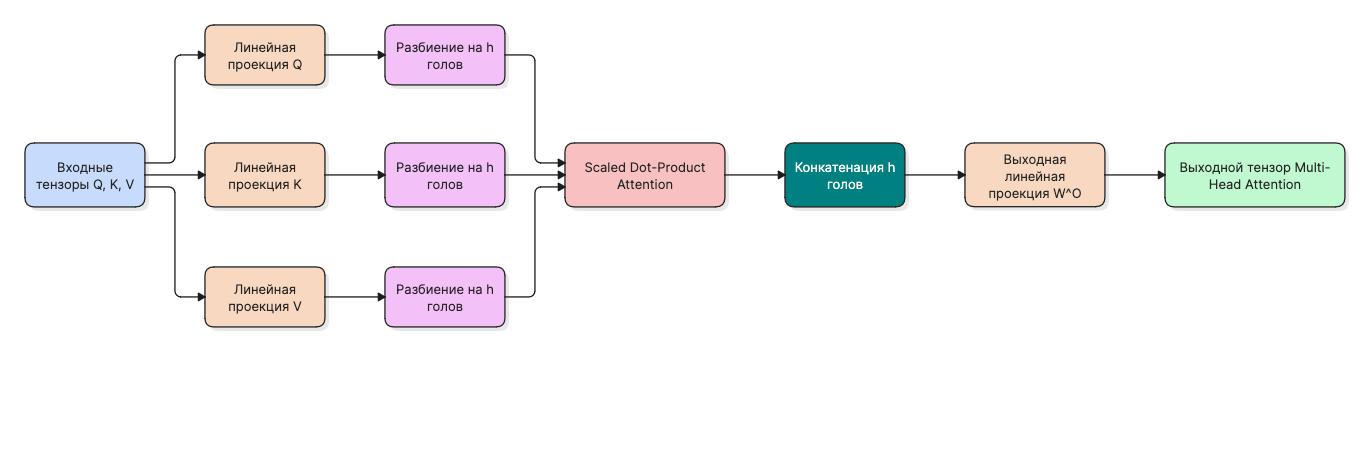

**Реализуйте:**
* Класс `MultiHeadAttention` с нуля, разделяющий входную размерность на заданное число голов.


In [14]:
class MultiHeadAttention(nn.Module):
    """
    Класс Multi-Head Attention с нуля на PyTorch.
    """

    def __init__(self, n_heads: int, d_model: int, dropout: float = 0.1):
        """
        Инициализация Multi-Head Attention.

        n_heads : int
            Количество голов внимания.
        d_model : int
            Размерность входной модели.
        dropout : float
            Значение вероятности dropout.
        """
        super().__init__()
        assert d_model % n_heads == 0

        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_model // n_heads

        #линейные слои для проекции Q, K, V
        self.q_project = nn.Linear(d_model, d_model, bias=False)
        self.k_project = nn.Linear(d_model, d_model, bias=False)
        self.v_project = nn.Linear(d_model, d_model, bias=False)

        #выхожной линейный слой для объединения голов внимания
        self.out_project = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Выполняет прямой проход Multi-Head Attention.

        x : torch.Tensor
            Входной тензор формы (batch, seq_len, d_model).
        mask : torch.Tensor, optional
            Маска внимания формы (seq_len, seq_len) или совместимая.

        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            output: выходной тензор той же формы, что и x (batch, seq_len, d_model),
            attn_weights: усредненные или по-головные веса внимания.
        """
        batch_size, seq_len, _ = x.shape
        q=self.q_project(x)
        k=self.k_project(x)
        v=self.v_project(x)
        #разделение голос через view и transpose для подготовки к scaled dot-product attention
        q=q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        k=k.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        v=v.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)

        out, attn_weights = scaled_dot_product_attention(q, k, v, mask)
        out=out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        out=self.out_project(out)

        return out, attn_weights


In [15]:
try:
    batch, seq_len, d_model, n_heads = 2, 8, 64, 4
    x = torch.randn(batch, seq_len, d_model)
    mha = MultiHeadAttention(n_heads=n_heads, d_model=d_model)
    output, attn = mha(x)
    
    assert output.shape == x.shape, f"Wrong output shape: {output.shape} != {x.shape}"
    assert attn.shape == (batch, n_heads, seq_len, seq_len), f"Wrong attention shape: {attn.shape}"
    
    print_ok("MultiHeadAttention базовый тест успешно пройден!")
except AssertionError as e:
    print_error(f"Тест MultiHeadAttention провален: {e}")

[OK] MultiHeadAttention базовый тест успешно пройден!


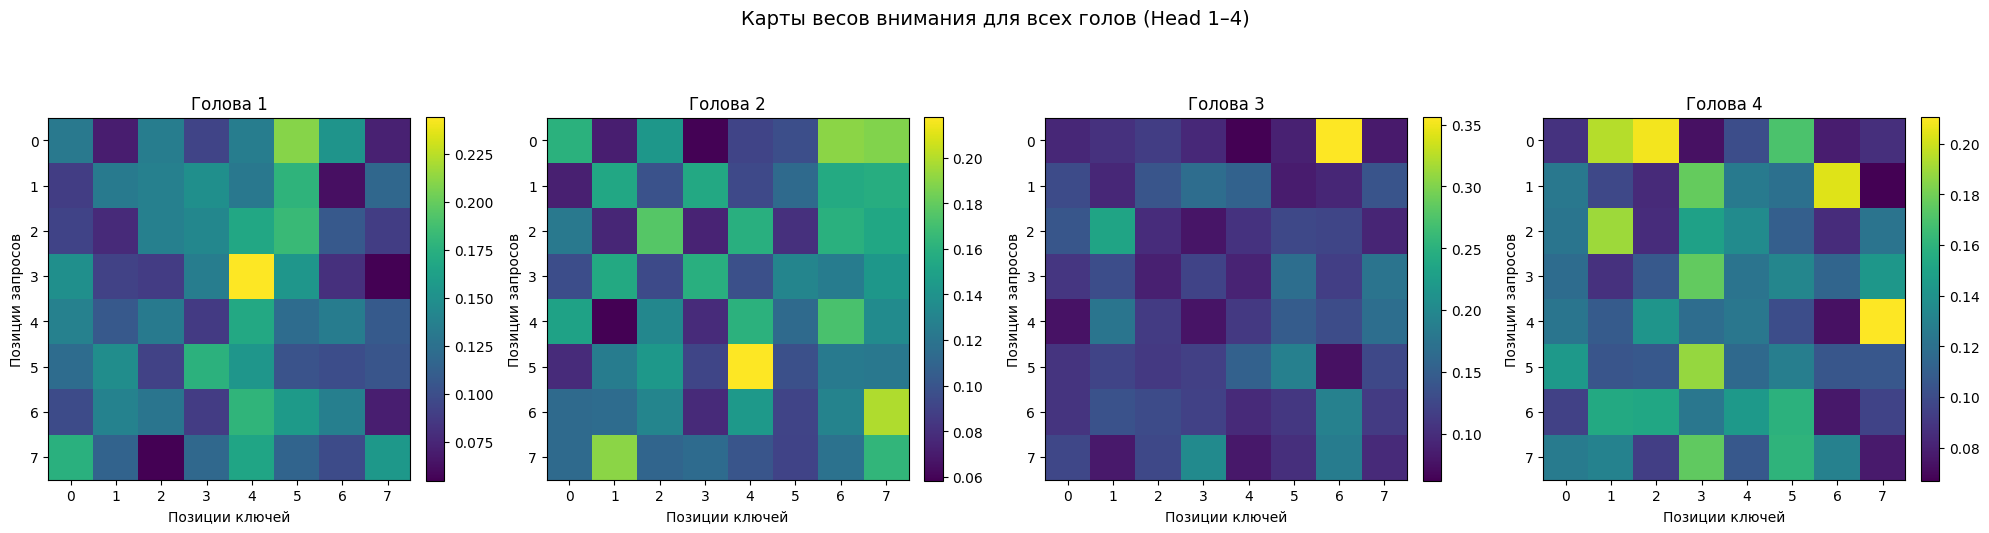

In [16]:
# Визуализация голов внимания
# ВАШ КОД ЗДЕСЬ: Отрисуйте тепловые карты весов внимания для всех голов
fig, axes = plt.subplots(1, n_heads, figsize=(20, 5))
for i in range(n_heads):
    #извлечение веса h-й головы внимания
    im = axes[i].imshow(attn[0, i].detach().cpu().numpy(), cmap='viridis')
    axes[i].set_title(f"Голова {i+1}")
    axes[i].set_xlabel("Позиции ключей")
    axes[i].set_ylabel("Позиции запросов")
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle("Карты весов внимания для всех голов (Head 1–4)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### ***Архитектурный пример***. Специализация голов при анализе кода

При анализе программного кода разные головы внимания могут специализироваться на разных типах связей:
* **Голова 1 (Скоуп/парность скобок)**: связывает открывающую и закрывающую скобки друг с другом.
* **Голова 2 (Поток данных)**: связывает имя переменной с местом её объявления.

Рассмотрим фрагмент: **"def f(x): return x + 1"**.


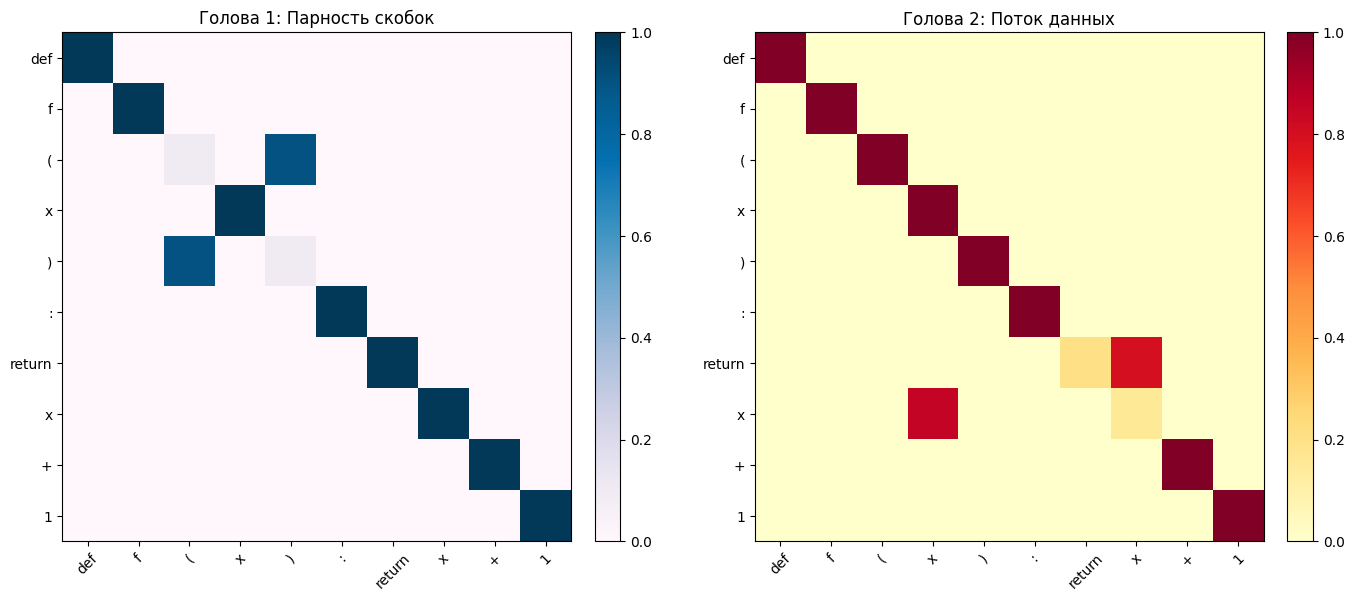

In [37]:
# Моделирование 2-голового внимания для фрагмента кода
tokens_mha = ["def", "f", "(", "x", ")", ":", "return", "x", "+", "1"]
seq_len_mha = len(tokens_mha)

# Голова 1: Фокус на скобках ( -> )
head1 = torch.eye(seq_len_mha)

head1[4] = torch.zeros(seq_len_mha)
head1[4, 2] = 0.9  # закрывающая на открывающую
head1[4, 4] = 0.1

head1[2] = torch.zeros(seq_len_mha)
head1[2, 4] = 0.9  # открывающая на закрывающую
head1[2, 2] = 0.1

# Голова 2: Фокус на потоке данных (return x -> x в сигнатуре)
head2 = torch.eye(seq_len_mha)
#x в теле функции связана с x в аргументах
head2[7] = torch.zeros(seq_len_mha)
head2[7, 3] = 0.85
head2[7, 7] = 0.15
# return связана с возвращаемым значением
head2[6] = torch.zeros(seq_len_mha)
head2[6, 7] = 0.80
head2[6, 6] = 0.20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

im1 = ax1.imshow(head1.numpy(), cmap="PuBu")
ax1.set_title("Голова 1: Парность скобок")
ax1.set_xticks(range(seq_len_mha))
ax1.set_yticks(range(seq_len_mha))
ax1.set_xticklabels(tokens_mha, rotation=45)
ax1.set_yticklabels(tokens_mha)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

im2 = ax2.imshow(head2.numpy(), cmap="YlOrRd")
ax2.set_title("Голова 2: Поток данных")
ax2.set_xticks(range(seq_len_mha))
ax2.set_yticks(range(seq_len_mha))
ax2.set_xticklabels(tokens_mha, rotation=45)
ax2.set_yticklabels(tokens_mha)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

> ***Вопрос на подумать***
>
> Зачем в Multi-Head Attention входные векторы Q, K, V проецируются на несколько «голов» внимания, вместо того чтобы применять одну большую голову на всю размерность? Какое преимущество это дает при анализе семантики предложения?
>
> ***Ответ:*** При использовании одной большой головы размерности d_model модель формирует единственное распределение softmax для каждого токена. Одна голова вынуждена усреднять разнородные связи, например, семантические, синтаксические, структурные и т.д., при этом теряя детали.

> Проекции переводят эмбеддинги в h независимых подпространств меньшей размерности d_k = d_model / h. Разные головы автономно специализируется на разных зависимостях.

> При этом суммарная вычислительная сложность не растёт h * O(N^2*d_k) = O(N^2 * d_model)

> Это наглядно подтверждают графики: Голова 1 выделила синтаксическую парность скобок ( и ) с взаимным весом 0.90, а Голова 2 сфокусировалась на потоке данных между return x и объявлением аргумента x с весом 0.85. Одна большая голова не смогла бы одновременно зафиксировать оба эти свойства без их смазывания.

# Задание 3. Causal Mask — причинная маска

В авторегрессионных генеративных моделях токен не должен иметь возможности смотреть в будущее. Causal Mask используется для маскирования будущих позиций.

**Реализуйте:**
* Функцию `create_causal_mask` для генерации булевой треугольной матрицы маски.


In [18]:
def create_causal_mask(seq_len: int) -> torch.Tensor:
    """
    Создает причинную маску для декодера.
    """
    mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool))
    return mask


In [19]:
try:
    seq_len = 6
    causal_mask = create_causal_mask(seq_len)
    
    # Базовые проверки маски
    assert causal_mask.shape == (seq_len, seq_len), "Неверная форма маски"
    assert causal_mask.dtype == torch.bool, "Тип данных маски должен быть torch.bool"
    assert (causal_mask.float().sum().item() == (seq_len * (seq_len + 1)) / 2), "Слишком много или слишком мало разрешенных токенов в маске"
    
    # Численные проверки Bidirectional vs Causal
    torch.manual_seed(42)
    q_dummy = torch.randn(1, 1, seq_len, 8)
    k_dummy = torch.randn(1, 1, seq_len, 8)
    v_dummy = torch.randn(1, 1, seq_len, 8)
    
    _, att_causal = scaled_dot_product_attention(q_dummy, k_dummy, v_dummy, mask=causal_mask)
    
    row_sums = att_causal[0, 0].sum(dim=-1)
    assert torch.allclose(row_sums, torch.ones_like(row_sums)), "Сумма по строкам в causal attention должна быть равна 1.0"
    
    upper_tri = torch.triu(att_causal[0, 0], diagonal=1)
    assert torch.allclose(upper_tri, torch.zeros_like(upper_tri)), "Элементы выше главной диагонали в causal attention должны быть равны 0.0"
    
    print_ok("Causal Mask и численные проверки пройдены успешно!")
except AssertionError as e:
    print_error(f"Тест Causal Mask провален: {e}")


[OK] Causal Mask и численные проверки пройдены успешно!


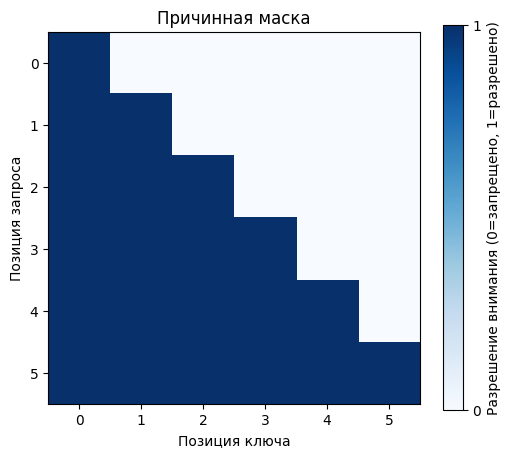

In [20]:
# Визуализация причинной маски
# ВАШ КОД ЗДЕСЬ: Отрисуйте причинную маску с помощью heatmap
mask = create_causal_mask(seq_len).float()

plt.figure(figsize=(6, 5))
plt.imshow(mask.numpy(), cmap='Blues', interpolation='nearest')
plt.colorbar(ticks=[0, 1], label='Разрешение внимания (0=запрещено, 1=разрешено)')
plt.title("Причинная маска")
plt.xlabel("Позиция ключа")
plt.ylabel("Позиция запроса")
plt.show()

### ***Архитектурный пример***. Причинность в авторегрессионной генерации

При автодополнении текста (например, в чат-боте) модель генерирует следующий токен, не имея доступа к токенам, которых ещё не существует.

Рассмотрим предложение: **"Кошка сидит на"** — модель должна предсказать продолжение (например, «коврике»), опираясь только на уже сгенерированный префикс.


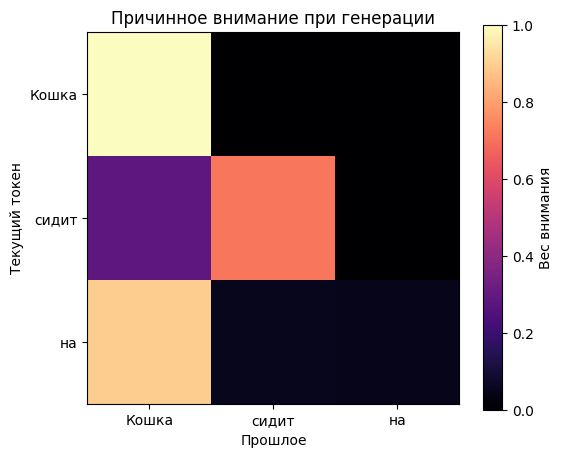

In [22]:
# Визуализация причинного внимания на тексте "Кошка сидит на"
# ВАШ КОД ЗДЕСЬ: Отрисуйте heatmap причинного внимания
tokens_causal = ["Кошка", "сидит", "на"]
seq_len_causal = len(tokens_causal)

torch.manual_seed(42) #генерация случайных Q,K для демонстрации softmax под маской
q_causal = torch.randn(1, 1, seq_len_causal, 16)
k_causal = torch.randn(1, 1, seq_len_causal, 16)
v_causal = torch.randn(1, 1, seq_len_causal, 16)

mask_causal = create_causal_mask(seq_len_causal)
_, attn_causal = scaled_dot_product_attention(q_causal, k_causal, v_causal, mask=mask_causal)

plt.figure(figsize=(6, 5))
plt.imshow(attn_causal[0, 0].detach().numpy(), cmap="magma")
plt.colorbar(label="Вес внимания")
plt.xticks(range(seq_len_causal), tokens_causal)
plt.yticks(range(seq_len_causal), tokens_causal)
plt.title("Причинное внимание при генерации")
plt.xlabel("Прошлое")
plt.ylabel("Текущий токен")
plt.show()


> ***Вопрос на подумать***
>
> Почему при использовании Causal Attention элементы выше главной диагонали в матрице внимания заполняются $-\infty$ (или очень большим отрицательным числом), а не просто нулями?
>
> ***Ответ:*** если заполнить позиции нулями, то экспонента от нуля равна единицу, в результате токены получает положительный числитель и ненулевую вероятность во взвешенной сумме. Приводит к утечке информации и модель начинает списывать ответ при обучении.

> если же заполнять позиции -inf, то предел экпоненты будет равен нулю и в результате вес внимания к будущим токенам становится равным 0.0, это исключает влияние ещё не сгенерированных токенов на текущее представление.

> Тепловая карта выше наглядно это показывает. В верхнем треугольнике черный цвет - абсолютный нуль. Слово "кошка" на шаге 0 смотрит на себя с весом 1.0 и физически не имеет доступа к будущим словам.

# Задание 4. KV-Cache — кеширование ключей и значений

### ***Архитектурная мотивация***. Инференс в продакшене

В движках инференса (vLLM, TensorRT-LLM, HuggingFace `generate()`) декодер генерирует токены по одному: на каждом шаге пересчитывать Key и Value для всех предыдущих токенов расточительно, ведь они не изменились с прошлого шага. KV-Cache сохраняет уже вычисленные $K$ и $V$ и на каждом шаге лишь дописывает данные нового токена, снижая сложность генерации одного токена с $O(n^2)$ до $O(n)$ — ценой роста потребления видеопамяти (VRAM) пропорционально длине контекста.

**Реализуйте:**
* Класс `KVCache` для накопления ключей и значений.
* Функцию `attention_with_cache` для применения кеша в механизме внимания.
* Бенчмарк для сравнения времени вычислений с кешем и без него.


In [23]:
class KVCache:
    """
    Класс для накопления и кеширования ключей (K) и значений (V) в процессе инференса.
    """

    def __init__(self):
        """
        Инициализация KV-кеша.
        """
        self.k_cache = None
        self.v_cache = None

    def update(self, k_new: torch.Tensor, v_new: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Добавляет новые ключи и значения в кеш.

        k_new : torch.Tensor
            Новый тензор ключей формы (batch, n_heads, 1, d_k).
        v_new : torch.Tensor
            Новый тензор значений формы (batch, n_heads, 1, d_v).

        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            k_cache: полный накопленный тензор K,
            v_cache: полный накопленный тензор V.
        """
        if self.k_cache is None:
            self.k_cache = k_new
            self.v_cache = v_new
        else: #конкатенация новых ключей и значений к существующему кешу
            self.k_cache = torch.cat([self.k_cache, k_new], dim=-2)
            self.v_cache = torch.cat([self.v_cache, v_new], dim=-2)
        return self.k_cache, self.v_cache

    def reset(self) -> None:
        """
        Сбрасывает закешированные значения.
        """
        self.k_cache = None
        self.v_cache = None

    @property
    def seq_len(self) -> int:
        """
        Текущая длина закешированной последовательности токенов.
        """
        if self.k_cache is None:
            return 0
        return self.k_cache.size(-2)


def attention_with_cache(
    q_new: torch.Tensor,
    k_new: torch.Tensor,
    v_new: torch.Tensor,
    cache: KVCache,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Вычисляет внимание для нового токена с использованием KV-кеша.

    q_new : torch.Tensor
        Query тензор нового токена формы (batch, n_heads, 1, d_k).
    k_new : torch.Tensor
        Key тензор нового токена формы (batch, n_heads, 1, d_k).
    v_new : torch.Tensor
        Value тензор нового токена формы (batch, n_heads, 1, d_v).
    cache : KVCache
        Объект KV-кеша.

    Returns
    -------
    Tuple[torch.Tensor, torch.Tensor]
        output: результат внимания формы (batch, n_heads, 1, d_v),
        attn_weights: веса внимания формы (batch, n_heads, 1, cache_seq_len).
    """
    # ВАШ КОД ЗДЕСЬ
    # 1. Обновите кеш вызовом cache.update(k_new, v_new), получив полные k_full, v_full
    k_full, v_full = cache.update(k_new, v_new)
    # 2. Вычислите scaled dot-product attention между q_new и полным кешем k_full, v_full
    output, attn_weights = scaled_dot_product_attention(q_new, k_full, v_full, mask=None)
    return output, attn_weights


In [24]:
try:
    test_cache = KVCache()
    assert test_cache.seq_len == 0, "Начальная длина кеша должна быть 0"
    
    k_test1 = torch.randn(1, 2, 1, 32)
    v_test1 = torch.randn(1, 2, 1, 32)
    k_full, v_full = test_cache.update(k_test1, v_test1)
    assert test_cache.seq_len == 1, "После одного обновления длина кеша должна быть 1"
    assert k_full.shape == (1, 2, 1, 32), "Неверная форма K после первого обновления"
    
    k_test2 = torch.randn(1, 2, 1, 32)
    v_test2 = torch.randn(1, 2, 1, 32)
    k_full, v_full = test_cache.update(k_test2, v_test2)
    assert test_cache.seq_len == 2, "После двух обновлений длина кеша должна быть 2"
    assert k_full.shape == (1, 2, 2, 32), "Неверная форма K после конкатенации"
    
    q_new = torch.randn(1, 2, 1, 32)
    output, _ = attention_with_cache(q_new, k_test2, v_test2, test_cache)
    assert output.shape == (1, 2, 1, 32), f"Неверная форма выхода внимания с кешем: {output.shape}"
    
    test_cache.reset()
    assert test_cache.seq_len == 0, "После сброса длина кеша должна быть 0"
    
    print_ok("KV-Cache и attention_with_cache успешно прошли тестирование!")
except AssertionError as e:
    print_error(f"Тест KV-Cache провален: {e}")

[OK] KV-Cache и attention_with_cache успешно прошли тестирование!


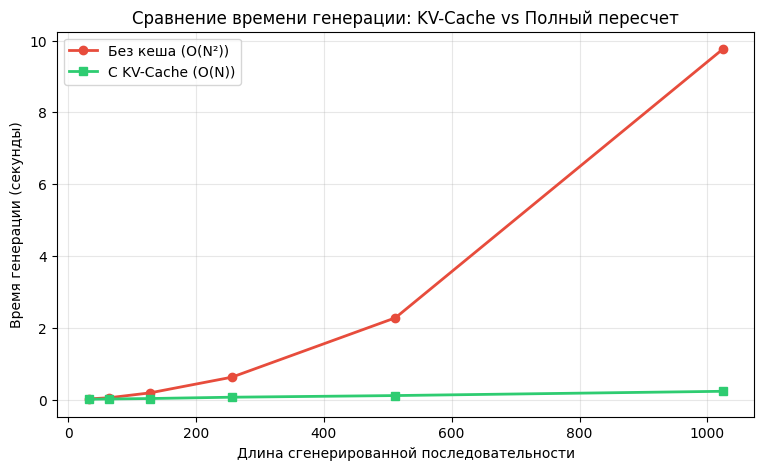

In [ ]:
# Бенчмарк KV-Cache
# ВАШ КОД ЗДЕСЬ: Сравните время генерации с KV-Cache и без него для разной длины последовательности и постройте график
seq_lengths = [32, 64, 128, 256, 512, 1024]
times_with_cache = []
times_without_cache = []

n_runs = 5
batch, n_heads, d_k= 1, 8, 64


for seq_len in seq_lengths:
    start_time = time.time() #без кеша, пересчет на каждом шаге
    for _ in range(n_runs):
        for step in range(1, seq_len+1):
            q_step = torch.randn(batch, n_heads, step, d_k)
            k_step = torch.randn(batch, n_heads, step, d_k)
            v_step = torch.randn(batch, n_heads, step, d_k)
            # внимание считает матрицу step x step
            _ = F.scaled_dot_product_attention(q_step, k_step, v_step, is_causal=True)
    times_without_cache.append((time.time() - start_time) / n_runs)

    сache = KVCache()
    start_time = time.time() #с кешем, считаем только 1 новый токен на каждом шаге
    for _ in range(n_runs):
        сache.reset()
        for step in range(1, seq_len+1):
            q_step = torch.randn(batch, n_heads, 1, d_k)
            k_step = torch.randn(batch, n_heads, 1, d_k)
            v_step = torch.randn(batch, n_heads, 1, d_k)
            _ = attention_with_cache(q_step, k_step, v_step, сache)
    times_with_cache.append((time.time() - start_time) / n_runs)

plt.figure(figsize=(9, 5))
plt.plot(seq_lengths, times_without_cache, "o-", label="Без кеша (O(N²))", color="#e74c3c", linewidth=2)
plt.plot(seq_lengths, times_with_cache, "s-", label="С KV-Cache (O(N))", color="#2ecc71", linewidth=2)
plt.xlabel("Длина сгенерированной последовательности")
plt.ylabel("Время генерации (секунды)")
plt.title("Сравнение времени генерации: KV-Cache vs Полный пересчет")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


> ***Вопрос на подумать***
>
> Во сколько раз снижается вычислительная сложность генерации $N$-го токена при использовании KV-Cache по сравнению с полным пересчетом? Какова цена использования KV-Cache с точки зрения оперативной памяти (VRAM)?
>
> ***Ответ:*** если проанализировать график бенчмарка, то при длине последовательности 1024 генерация без кеша заняла 9.8 секунд, в то время как с KV-кешем то же самое выполнилось за 0.22 секунды, что дало ускорение примерно в 44 раза.

> Без KV-кеша модель, чтобы получить n-ый токен, вынуждена подать на вход всю предысторию длины N, снова вычислять линейные проекции и для всех N токенов и пересчитать полную матрицу внимания N x N. С KV-кешем ключи и значения предыдущих N-1 токенов уже находятся в памяти. Вычисления происходят только для 1 нового токена. Таким образом для генерации N-ного токена вычислительная сложность снижается в N раз.

> Объём памяти VRAM растет строго линейно с ростом длины контекста и размера батча. В памяти хранятся 2 независимые матрицы K и V, при больших размерах батча объём KV-кеша начинает превышать вес самой модели -> узкое горлышко по памяти. Отсюда появились разного рода оптимизации, например, PagedAttention (vLLM).

# Задание 5. Сравнение позиционных кодировок

Механизм внимания инвариантен к порядку токенов. Для внесения информации о позициях используются кодировки.

### ***Архитектурная мотивация***. Выбор PE в реальных моделях

Выбор схемы позиционного кодирования — не только теоретический вопрос, но и инженерное решение: от него зависит, насколько модель способна работать с контекстом длиннее, чем видела при обучении (экстраполяция). Learned PE (GPT-2, BERT) жёстко ограничен максимальной длиной, заданной на этапе обучения. Sinusoidal PE формально определён для любой длины, но на практике плохо экстраполируется. Именно поэтому почти все современные open-source LLM (LLaMA, Mistral, Qwen) выбрали RoPE — он естественно обобщается на более длинные контексты и легче комбинируется с техниками растяжения контекста (NTK-scaling, YaRN).

**Реализуйте:**
* Классы позиционного кодирования: синусоидального (`SinusoidalPositionalEncoding`), обучаемого (`LearnedPositionalEncoding`) и ротационного (`RoPE`).


In [26]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model) #создание матрицы позиций
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term) #синус для четных индексов
        pe[:, 1::2] = torch.cos(position * div_term) #косинус для нечетных индексов

        self.register_buffer('pe', pe.unsqueeze(0)) #доблавление как буфер, не обучается, но сохраняется с моделью
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

In [27]:
try:
    d_model_pe = 64
    seq_len_pe = 20
    sin_pe = SinusoidalPositionalEncoding(d_model_pe)
    x_pe = torch.randn(1, seq_len_pe, d_model_pe)
    out_sin = sin_pe(x_pe)
    
    assert out_sin.shape == x_pe.shape, f"Wrong shape: {out_sin.shape}"
    print_ok("Sinusoidal PE успешно пройдена!")
except AssertionError as e:
    print_error(f"Тест Sinusoidal PE провален: {e}")


[OK] Sinusoidal PE успешно пройдена!


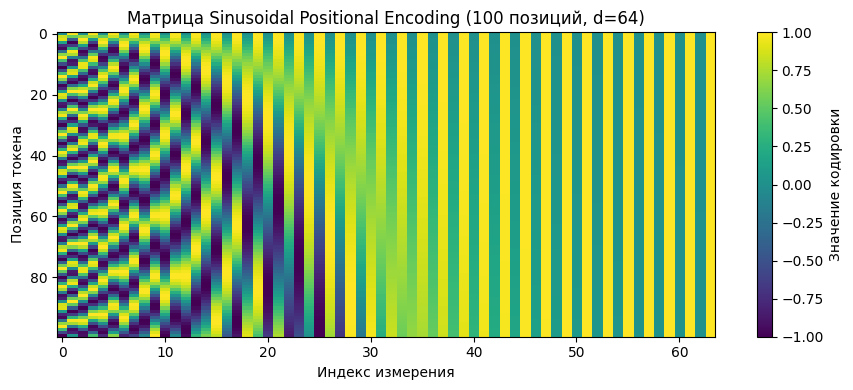

In [28]:
# Визуализация Sinusoidal PE
sin_module = SinusoidalPositionalEncoding(d_model=64, max_len=100)
plt.figure(figsize=(9, 4))
plt.imshow(sin_module.pe[0, :100].detach().cpu().numpy(), cmap="viridis", aspect="auto")
plt.colorbar(label="Значение кодировки")
plt.title("Матрица Sinusoidal Positional Encoding (100 позиций, d=64)")
plt.xlabel("Индекс измерения")
plt.ylabel("Позиция токена")
plt.tight_layout()
plt.show()

In [ ]:
class LearnedPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)  # обучаемая матрица позиций, масштабируем стандартое отклонение

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


In [30]:
try:
    learned_pe = LearnedPositionalEncoding(d_model_pe)
    out_learned = learned_pe(x_pe)
    
    assert out_learned.shape == x_pe.shape, f"Wrong shape: {out_learned.shape}"
    assert isinstance(learned_pe.pe, nn.Parameter), "Позиции должны быть обучаемым nn.Parameter"
    print_ok("Learned PE успешно пройдена!")
except AssertionError as e:
    print_error(f"Тест Learned PE провален: {e}")


[OK] Learned PE успешно пройдена!


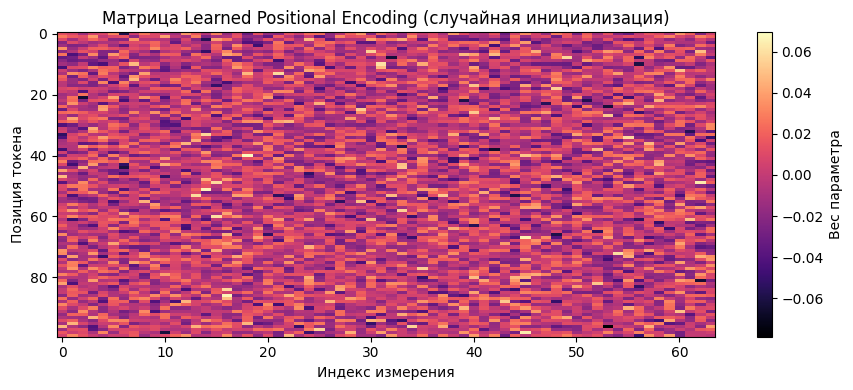

In [31]:
# Визуализация Learned PE
learned_module = LearnedPositionalEncoding(d_model=64, max_len=100)
plt.figure(figsize=(9, 4))
plt.imshow(learned_module.pe[0, :100].detach().cpu().numpy(), cmap="magma", aspect="auto")
plt.colorbar(label="Вес параметра")
plt.title("Матрица Learned Positional Encoding (случайная инициализация)")
plt.xlabel("Индекс измерения")
plt.ylabel("Позиция токена")
plt.tight_layout()
plt.show()

In [32]:
class RoPE(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        self.d_model = d_model
        #вычисление базовой частоты
        theta = 1.0 / (10000 ** (torch.arange(0, d_model, 2).float() / d_model))
        position = torch.arange(0, max_len).float()
        #pos * theta -> (max_len, d_model // 2)
        freqs = torch.outer(position, theta)
        #дублирование для применения к парам
        emb = torch.cat([freqs, freqs], dim=-1)
        self.register_buffer("cos_cached", emb.cos())
        self.register_buffer("sin_cached", emb.sin())

    def _rotate_half(self, x: torch.Tensor) -> torch.Tensor:
        # поворот второй половины вектора [-x2, x1]
        x1 = x[..., : self.d_model // 2]
        x2 = x[..., self.d_model // 2 :]
        return torch.cat((-x2, x1), dim=-1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(-2)
        cos = self.cos_cached[:seq_len]
        sin = self.sin_cached[:seq_len]
        
        # x * cos + rotate_half(x) * sin
        return (x * cos) + (self._rotate_half(x) * sin)

In [33]:
try:
    rope_test = RoPE(d_model=64)
    q_test = torch.randn(1, 2, seq_len_pe, 64)
    q_rope = rope_test(q_test)
    assert q_rope.shape == q_test.shape, "Форма выхода RoPE должна совпадать с формой входа"
    
    # Для pos=0 RoPE не должен изменять значения
    assert torch.allclose(q_rope[:, :, 0], q_test[:, :, 0], atol=1e-5), "Для первой позиции (pos=0) RoPE не должен изменять значения"
    print_ok("RoPE успешно прошел тестирование!")
except AssertionError as e:
    print_error(f"Тест RoPE провален: {e}")


[OK] RoPE успешно прошел тестирование!


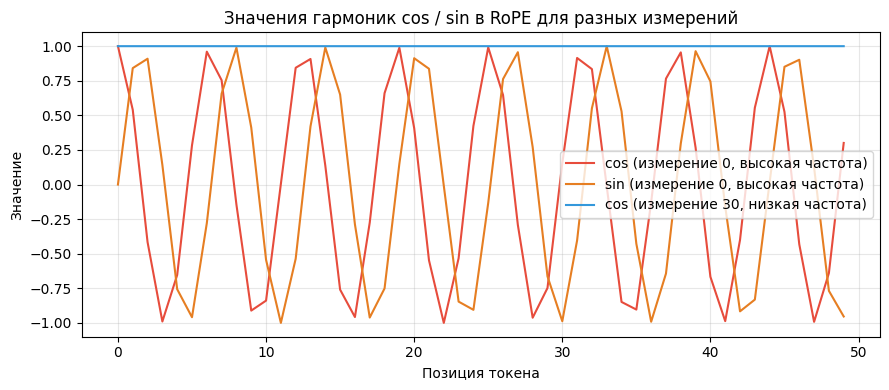

In [34]:
# Визуализация RoPE
# ВАШ КОД ЗДЕСЬ: Постройте график значений cos/sin для RoPE
rope_mod = RoPE(d_model=64, max_len=100)
plt.figure(figsize=(9, 4))
plt.plot(rope_mod.cos_cached[:50, 0].cpu().numpy(), label="cos (измерение 0, высокая частота)", color="#e74c3c")
plt.plot(rope_mod.sin_cached[:50, 0].cpu().numpy(), label="sin (измерение 0, высокая частота)", color="#e67e22")
plt.plot(rope_mod.cos_cached[:50, 30].cpu().numpy(), label="cos (измерение 30, низкая частота)", color="#3498db")
plt.xlabel("Позиция токена")
plt.ylabel("Значение")
plt.title("Значения гармоник cos / sin в RoPE для разных измерений")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


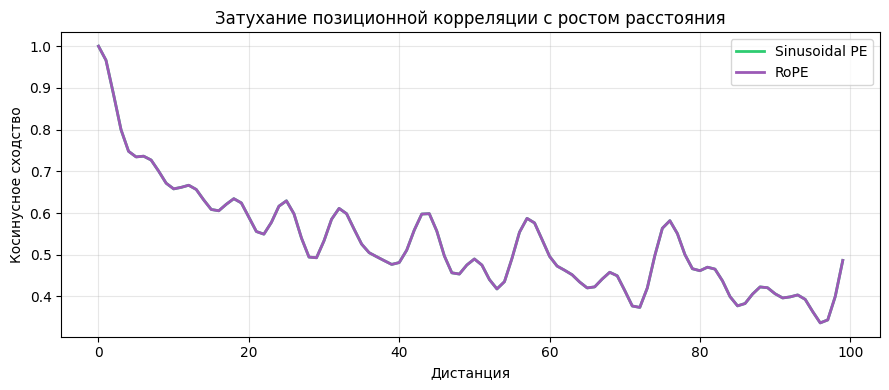

In [36]:
# Сравнение позиционных сходств (decay)
# ВАШ КОД ЗДЕСЬ: Постройте графики затухания корреляции весов PE для разных позиций
sin_mat = sin_module.pe[0, :100]
sin_sim = F.cosine_similarity(sin_mat[0:1], sin_mat, dim=-1)

# модуляция скалярного произведения повернутого вектора
q_init = torch.ones(1, 1, 100, 64)
q_rot = rope_mod(q_init)[0, 0]
rope_sim = F.cosine_similarity(q_rot[0:1], q_rot, dim=-1)

plt.figure(figsize=(9, 4))
plt.plot(sin_sim.detach().cpu().numpy(), label="Sinusoidal PE", color="#2ecc71", linewidth=2)
plt.plot(rope_sim.detach().cpu().numpy(), label="RoPE", color="#9b59b6", linewidth=2)
plt.xlabel("Дистанция")
plt.ylabel("Косинусное сходство")
plt.title("Затухание позиционной корреляции с ростом расстояния")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


> ***Вопрос на подумать***
>
> 1. В чем ключевое отличие абсолютного позиционного кодирования (например, Sinusoidal PE) от относительного (например, RoPE)? Почему RoPE лучше подходит для работы с контекстными окнами большой длины?
> 2. ***Инженерный вопрос***: Почему GPT-2 и BERT использовали Learned/Sinusoidal PE, а почти все современные open-source LLM (LLaMA, Mistral, Qwen) перешли на RoPE? Какое практическое ограничение стало решающим при выборе?
>
> ***Ответ:*** 

> 1. Абсолютное кодирование прибавляется непосредственно к входным эмбеддингам (x+PE), чтобы определить взаимную дистанцию между токенами i и j, слои внимания вынуждены заставлять обучаемые матрицы производить процесс вычитания абсолютных векторов. 

> Относительное кодирование встраивается внутрь скалярного произведения через поворот векторов, где скалярное произведение зависит исключительно от относительной дистанции, а асболютные номера позиций взаимо уничтожаются.

> На последнем графике, затухание корреляции, видно, что косинусное сходство токена с pos=0 монотонно падает с 1.0 до ~0.35 при удалении на 100 позиций, что подтверждает свойство долгосрочного затухания.

> В RoPE оно возникает, потому что по мере роста дистанции скалярное произведение ключа и запроса плавно стремится к нулю. Модель избавляется от ложных связей на больших расстояниях и позволяет масштабировать контекстное окно без переобучения модели с нуля, в этом плюс для работы с контекстными окнами большой длины.

> 2. Решающим фактором стало катастрофическое ограничение по длине контекста и невозможность экстраполяции. В ранних моделях модель не могла принять на вход даже на 1 токен больше обучающего лимита, если так было, то код падал с ошибкой выхода за границы. При использовании Sinusoidal PE и выходе за пределы обучающей генерации качество генерации деградировало, так как модель видела не встречашиеся при обучении комбинации высоких частот, в то время как, переход на RoPE обеспечил стабильное относительное внимание и контекстные окна на сотни тысяч токенов.



---



## Итоги

Вы реализовали и проверили:

| # | Компонент | Что сделано |
|---|-----------|-------------|
| T1 | Scaled Dot-Product Attention | Реализация с нуля, сравнение с PyTorch, градиенты |
| T2 | Multi-Head Attention | Класс MHA, визуализация голов, анализ энтропии |
| T3 | Causal Mask | Причинная маска, bidirectional vs causal сравнение |
| T4 | KV-Cache | Кеширование K/V, бенчмарк ускорения, анализ сложности |
| T5 | Positional Encoding | Sinusoidal, Learned, RoPE — сравнение сходства |

### Что сдавать

1. Выполненный ноутбук со всеми ячейками
2. Выводы по каждому заданию (где отмечено)

### Бонусные задания

- **T1\***: Реализовать `MultiQueryAttention` (общие K, V для всех голов)
- **T3\***: Реализовать sliding window attention с causal mask
- **T4\***: Реализовать блочный KV-Cache с pruning старых токенов
- **T5\***: Сравнить RoPE с другими относительными PE (ALiBi, XPos)


---
# Ссылки и полезные материалы

- [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762)
- [Rotary Position Embedding (RoPE) paper (Su et al., 2021)](https://arxiv.org/abs/2104.09864)
- [Hugging Face LLM tutorial on KV-Cache](https://huggingface.co/docs/transformers/llm_tutorial)
- [Illustrated Transformer by Jay Alammar](https://jalammar.github.io/illustrated-transformer/)
